# 第 9 章 · BPE 代码实验

本页用经典英文词频语料演示子词合并。读者重点看每一轮最高频相邻符号是什么，以及 token 总数如何下降。

[章节网页](../ch9.html)

## 运行内容

- 准备字符级词表
- 执行 merge 步骤
- 绘制 pair 频次

## 0. 词频语料

先把单词拆成字符序列，并保留每个单词出现频次。高频词会对合并选择产生更大影响。

In [1]:
# 载入本页会用到的数据集、模型和绘图工具。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.signal import correlate2d
from sklearn.datasets import load_breast_cancer, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 准备带频次的 BPE 语料，把每个词拆成字符序列。
word_freq = {
    "low": 5,
    "lower": 2,
    "newest": 6,
    "widest": 3,
    "newer": 4,
}
vocab = Counter({tuple(word) + ("</w>",): freq for word, freq in word_freq.items()})

def pair_counts(vocab):
    counts = Counter()
    for symbols, freq in vocab.items():
        for i in range(len(symbols) - 1):
            counts[(symbols[i], symbols[i + 1])] += freq
    return counts


def merge_pair(vocab, pair):
    merged = {}
    bigram = " ".join(pair)
    replacement = "".join(pair)
    for symbols, freq in vocab.items():
        text = " ".join(symbols)
        new_symbols = tuple(text.replace(bigram, replacement).split())
        merged[new_symbols] = freq
    return Counter(merged)


def weighted_token_count(vocab):
    return sum(len(symbols) * freq for symbols, freq in vocab.items())


display(pd.DataFrame({
    "word": list(word_freq.keys()),
    "频次": list(word_freq.values()),
    "初始token序列": [" ".join(tuple(word) + ("</w>",)) for word in word_freq],
}))
print("初始加权 token 数:", weighted_token_count(vocab))

,word,频次,初始token序列
0,low,5,l o w </w>
1,lower,2,l o w e r </w>
2,newest,6,n e w e s t </w>
3,widest,3,w i d e s t </w>
4,newer,4,n e w e r </w>


初始加权 token 数: 119


## 1. 合并过程

每一轮选择当前最高频 pair，把它合并成更长的子词。图表同时展示选择依据和压缩效果。

In [3]:
# 连续执行若干次 merge，记录每轮最高频 pair 和 token 数变化。
bpe_rows = []
history = []
current_vocab = vocab.copy()
token_totals = [weighted_token_count(current_vocab)]

for step in range(1, 7):
    counts = pair_counts(current_vocab)
    best_pair, best_count = counts.most_common(1)[0]
    before_total = weighted_token_count(current_vocab)
    current_vocab = merge_pair(current_vocab, best_pair)
    after_total = weighted_token_count(current_vocab)
    token_totals.append(after_total)
    state = [" ".join(symbols) for symbols in current_vocab.keys()]
    bpe_rows.append({
        "轮次": step,
        "合并pair": " + ".join(best_pair),
        "频次": best_count,
        "token数": f"{before_total} → {after_total}",
        "减少": before_total - after_total,
        "当前token序列": " | ".join(state),
    })
    history.append((best_pair, best_count, counts, before_total, after_total))

bpe_trace = pd.DataFrame(bpe_rows)
display(bpe_trace)

,轮次,合并pair,频次,token数,减少,当前token序列
0,1,w + e,12,119 → 107,12,l o w </w> | l o we r </w> | n e we s t </w> |...
1,2,n + e,10,107 → 97,10,l o w </w> | l o we r </w> | ne we s t </w> | ...
2,3,ne + we,10,97 → 87,10,l o w </w> | l o we r </w> | newe s t </w> | w...
3,4,s + t,9,87 → 78,9,l o w </w> | l o we r </w> | newe st </w> | w ...
4,5,st + </w>,9,78 → 69,9,l o w </w> | l o we r </w> | newe st</w> | w i...
5,6,l + o,7,69 → 62,7,lo w </w> | lo we r </w> | newe st</w> | w i d...


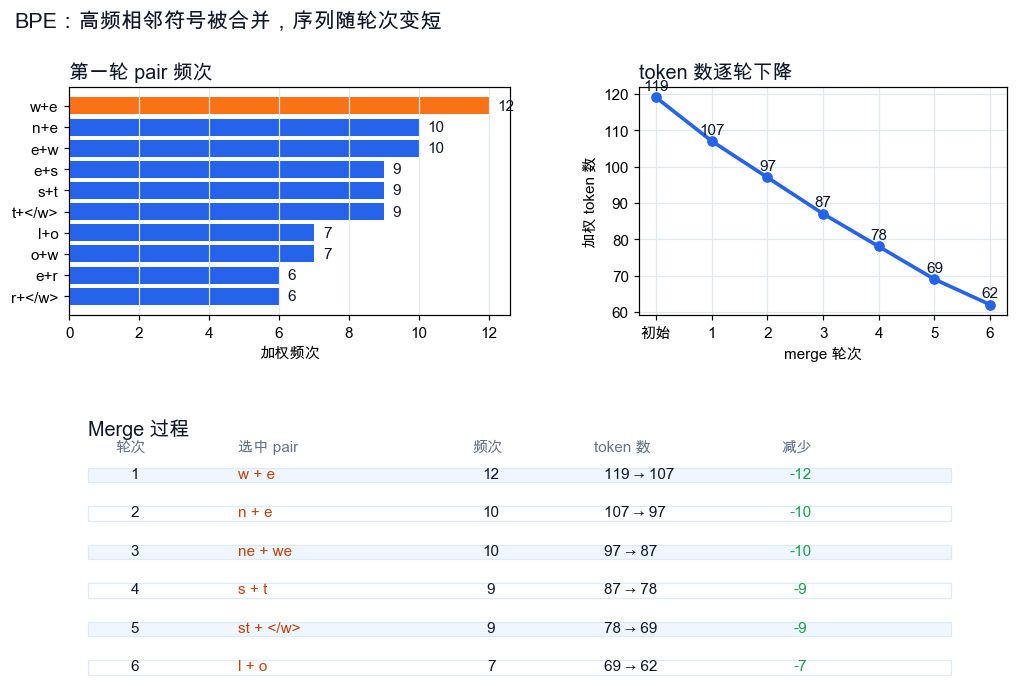

In [4]:
# 展示第一轮选择依据和连续 merge 后的压缩过程。
first_pair, _, first_counts, _, _ = history[0]
top_pairs = first_counts.most_common(10)
pair_labels = ["+".join(pair) for pair, _ in top_pairs]
pair_values = [count for _, count in top_pairs]
pair_colors = ["#f97316" if pair == first_pair else "#2563eb" for pair, _ in top_pairs]

fig = plt.figure(figsize=(11.0, 7.0))
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.15], width_ratios=[1.2, 1.0], hspace=0.42, wspace=0.32)

ax1 = fig.add_subplot(gs[0, 0])
y = np.arange(len(pair_labels))
ax1.barh(y, pair_values, color=pair_colors)
ax1.set_yticks(y, pair_labels)
ax1.invert_yaxis()
ax1.set_xlabel("加权频次")
ax1.set_title("第一轮 pair 频次", loc="left", fontsize=13, fontweight="bold", color="#0f172a")
for idx, value in enumerate(pair_values):
    ax1.text(value + 0.25, idx, str(value), va="center", color="#0f172a", fontweight="bold" if idx == 0 else "normal")
ax1.grid(True, axis="x", color="#e2e8f0", linewidth=0.8)

ax2 = fig.add_subplot(gs[0, 1])
steps = np.arange(len(token_totals))
ax2.plot(steps, token_totals, marker="o", linewidth=2.4, color="#2563eb")
for x, value in zip(steps, token_totals):
    ax2.text(x, value + 2.0, str(value), ha="center", color="#0f172a")
ax2.set_xticks(steps, ["初始"] + [str(i) for i in range(1, len(token_totals))])
ax2.set_xlabel("merge 轮次")
ax2.set_ylabel("加权 token 数")
ax2.set_title("token 数逐轮下降", loc="left", fontsize=13, fontweight="bold", color="#0f172a")
ax2.grid(True, color="#e2e8f0", linewidth=0.8)

ax3 = fig.add_subplot(gs[1, :])
ax3.set_xlim(0, 1)
ax3.set_ylim(0, len(bpe_trace) + 0.8)
ax3.axis("off")
ax3.text(0.02, len(bpe_trace) + 0.35, "Merge 过程", fontsize=13, fontweight="bold", color="#0f172a")
ax3.text(0.05, len(bpe_trace) - 0.05, "轮次", color="#64748b", fontweight="bold")
ax3.text(0.18, len(bpe_trace) - 0.05, "选中 pair", color="#64748b", fontweight="bold")
ax3.text(0.43, len(bpe_trace) - 0.05, "频次", color="#64748b", fontweight="bold")
ax3.text(0.56, len(bpe_trace) - 0.05, "token 数", color="#64748b", fontweight="bold")
ax3.text(0.76, len(bpe_trace) - 0.05, "减少", color="#64748b", fontweight="bold")

for idx, row in bpe_trace.iterrows():
    y = len(bpe_trace) - idx - 0.65
    ax3.add_patch(plt.Rectangle((0.02, y - 0.22), 0.92, 0.38, color="#eff6ff" if idx % 2 == 0 else "#ffffff", ec="#dbeafe", lw=0.8))
    ax3.text(0.07, y, str(row["轮次"]), ha="center", va="center", color="#0f172a", fontweight="bold")
    ax3.text(0.18, y, row["合并pair"], ha="left", va="center", color="#c2410c", fontweight="bold")
    ax3.text(0.45, y, str(row["频次"]), ha="center", va="center", color="#0f172a")
    ax3.text(0.57, y, row["token数"], ha="left", va="center", color="#0f172a")
    ax3.text(0.78, y, f"-{row['减少']}", ha="center", va="center", color="#16a34a", fontweight="bold")

fig.suptitle("BPE：高频相邻符号被合并，序列随轮次变短", x=0.08, ha="left", fontsize=14, fontweight="bold", color="#0f172a")
plt.tight_layout()
plt.show()